In [9]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

DATA_DIR = Path("../data/raw")


In [10]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

file_inventory = pd.DataFrame(
    {
        "file_name": [path.name for path in csv_files],
        "size_mb": [
            round(path.stat().st_size / (1024**2), 2)
            for path in csv_files
        ],
    }
)

file_inventory

,file_name,size_mb
0,application_test.csv,25.34
1,application_train.csv,158.44
2,bureau.csv,162.14
3,bureau_balance.csv,358.19
4,credit_card_balance.csv,404.91
5,HomeCredit_columns_description.csv,0.04
6,installments_payments.csv,689.62
7,POS_CASH_balance.csv,374.51
8,previous_application.csv,386.21
9,sample_submission.csv,0.51


In [11]:
application = pd.read_csv(
    DATA_DIR / "application_train.csv",
    low_memory=False,
)

print(f"Nombre de lignes    : {application.shape[0]:,}")
print(f"Nombre de colonnes  : {application.shape[1]:,}")
print(f"Mémoire utilisée    : "
      f"{application.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

application.head()

Nombre de lignes    : 307,511
Nombre de colonnes  : 122
Mémoire utilisée    : 536.69 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
def dataframe_overview(df: pd.DataFrame) -> pd.Series:
    """Return the main structural diagnostics of a DataFrame."""
    return pd.Series(
        {
            "n_rows": len(df),
            "n_columns": df.shape[1],
            "duplicated_rows": df.duplicated().sum(),
            "duplicated_ids": df["SK_ID_CURR"].duplicated().sum(),
            "missing_cells": df.isna().sum().sum(),
            "missing_percentage": (
                100 * df.isna().sum().sum() / df.size
            ),
            "numeric_columns": df.select_dtypes(
                include=np.number
            ).shape[1],
            "categorical_columns": df.select_dtypes(
                exclude=np.number
            ).shape[1],
        }
    )

overview = dataframe_overview(application)
overview

n_rows                 3.075110e+05
n_columns              1.220000e+02
duplicated_rows        0.000000e+00
duplicated_ids         0.000000e+00
missing_cells          9.152465e+06
missing_percentage     2.439594e+01
numeric_columns        1.060000e+02
categorical_columns    1.600000e+01
dtype: float64

In [13]:
assert "SK_ID_CURR" in application.columns
assert "TARGET" in application.columns
assert application["SK_ID_CURR"].is_unique
assert application["TARGET"].notna().all()
assert set(application["TARGET"].unique()) == {0, 1}

print("Contrôles structurels validés.")

Contrôles structurels validés.


In [14]:
dtype_summary = (
    application.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="number_of_columns")
)

dtype_summary

,dtype,number_of_columns
0,float64,65
1,int64,41
2,object,16


In [15]:
categorical_columns = application.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = application.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Variables catégorielles : {len(categorical_columns)}")
print(f"Variables numériques    : {len(numerical_columns)}")

categorical_columns[:20]

Variables catégorielles : 16
Variables numériques    : 106


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [16]:
categorical_summary = []

for column in categorical_columns:
    categorical_summary.append(
        {
            "feature": column,
            "n_unique": application[column].nunique(dropna=True),
            "missing_pct": application[column].isna().mean() * 100,
            "most_frequent": application[column].mode(
                dropna=True
            ).iloc[0],
        }
    )

categorical_summary = (
    pd.DataFrame(categorical_summary)
    .sort_values("n_unique", ascending=False)
)

categorical_summary.head(20)

,feature,n_unique,missing_pct,most_frequent
11,ORGANIZATION_TYPE,58,0.000000,Business Entity Type 3
9,OCCUPATION_TYPE,18,31.345545,Laborers
5,NAME_INCOME_TYPE,8,0.000000,Working
4,NAME_TYPE_SUITE,7,0.420148,Unaccompanied
10,WEEKDAY_APPR_PROCESS_START,7,0.000000,TUESDAY
14,WALLSMATERIAL_MODE,7,50.840783,Panel
7,NAME_FAMILY_STATUS,6,0.000000,Married
8,NAME_HOUSING_TYPE,6,0.000000,House / apartment
6,NAME_EDUCATION_TYPE,5,0.000000,Secondary / secondary special
12,FONDKAPREMONT_MODE,4,68.386172,reg oper account


In [17]:
target_counts = (
    application["TARGET"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No payment difficulty", 1: "Payment difficulty"})
)

target_rates = (
    application["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={0: "No payment difficulty", 1: "Payment difficulty"})
)

target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "percentage": target_rates,
    }
)

target_summary

,count,percentage
TARGET,,
No payment difficulty,282686,91.927118
Payment difficulty,24825,8.072882


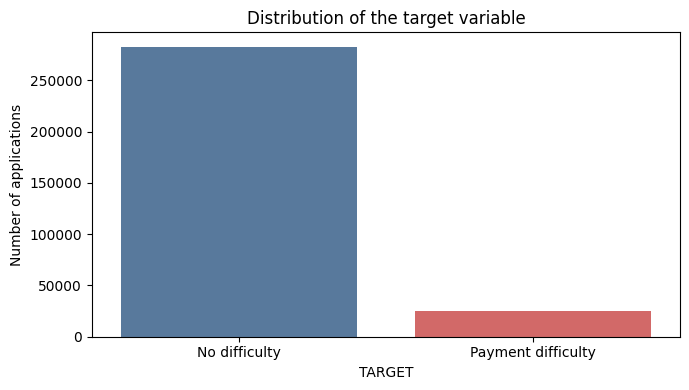

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(
    data=application,
    x="TARGET",
    hue="TARGET",
    palette={0: "#4C78A8", 1: "#E45756"},
    legend=False,
    ax=ax,
)

ax.set_title("Distribution of the target variable")
ax.set_xlabel("xTARGET")
ax.set_ylabel("Number of applications")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No difficulty", "Payment difficulty"])

plt.tight_layout()
plt.show()

Le dataset est déséquilibré. En revanche:
- l'accuracy sera trompeuse
- le split devra être stratifié;
- le PR-AUC sera particulièrement utile;
- le seuil 0.5 ne devra pas être choisi automatiquement;
- l'échantillonnage ou les poids de classes devront être comparés.

In [21]:
missing_summary = (
    application.isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .to_frame()
)

missing_summary["dtype"] = application.dtypes.astype(str)

missing_summary = (
    missing_summary
    .sort_values("missing_pct", ascending=False)
)

missing_summary.head(20)

,missing_pct,dtype
COMMONAREA_MEDI,69.872297,float64
COMMONAREA_AVG,69.872297,float64
COMMONAREA_MODE,69.872297,float64
NONLIVINGAPARTMENTS_MODE,69.432963,float64
NONLIVINGAPARTMENTS_AVG,69.432963,float64
NONLIVINGAPARTMENTS_MEDI,69.432963,float64
FONDKAPREMONT_MODE,68.386172,object
LIVINGAPARTMENTS_MODE,68.354953,float64
LIVINGAPARTMENTS_AVG,68.354953,float64
LIVINGAPARTMENTS_MEDI,68.354953,float64


In [23]:
for threshold in [0, 20, 40, 60, 80]:
    n_columns = (missing_summary["missing_pct"] > threshold).sum()
    print(
        f"Colonnes avec plus de {threshold}% de valeurs manquantes: "
        f"{n_columns}"
    )

Colonnes avec plus de 0% de valeurs manquantes: 67
Colonnes avec plus de 20% de valeurs manquantes: 50
Colonnes avec plus de 40% de valeurs manquantes: 49
Colonnes avec plus de 60% de valeurs manquantes: 17
Colonnes avec plus de 80% de valeurs manquantes: 0


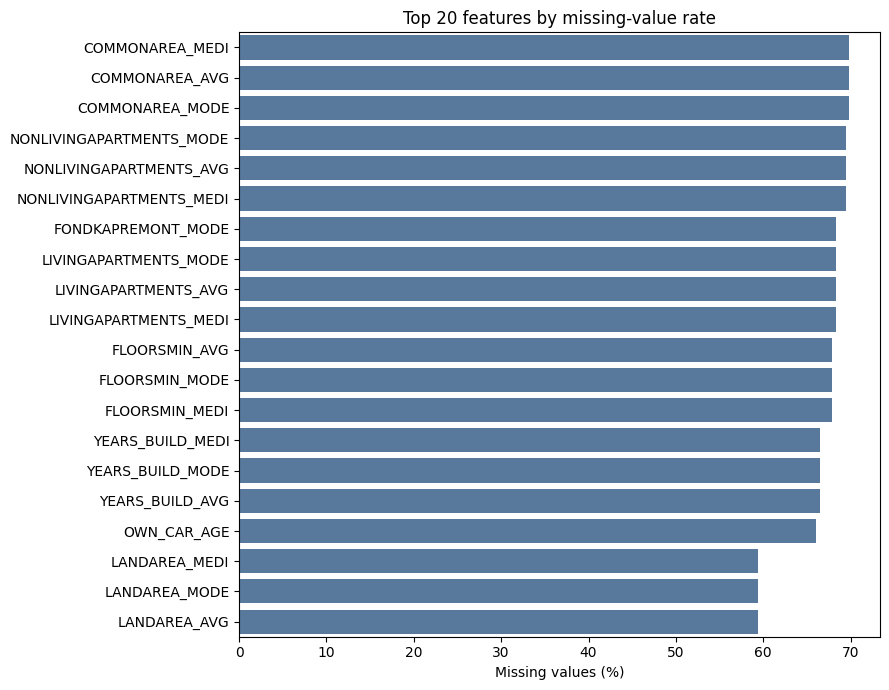

In [22]:
top_missing = missing_summary.head(20).reset_index()
top_missing = top_missing.rename(columns={"index": "feature"})

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    data=top_missing,
    y="feature",
    x="missing_pct",
    color="#4C78A8",
    ax=ax,
)

ax.set_title("Top 20 features by missing-value rate")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [24]:
feature_cardinality = pd.DataFrame(
    {
        "feature": application.columns,
        "n_unique": [
            application[column].nunique(dropna=False)
            for column in application.columns
        ],
    }
)

constant_features = feature_cardinality.query("n_unique <= 1")
near_identifier_features = feature_cardinality.sort_values(
    "n_unique",
    ascending=False,
).head(20)

constant_features

,feature,n_unique


In [25]:
near_identifier_features

,feature,n_unique
0,SK_ID_CURR,307511
42,EXT_SOURCE_2,119832
41,EXT_SOURCE_1,114585
17,DAYS_BIRTH,17460
19,DAYS_REGISTRATION,15688
9,AMT_ANNUITY,13673
18,DAYS_EMPLOYED,12574
20,DAYS_ID_PUBLISH,6168
8,AMT_CREDIT,5603
69,LIVINGAREA_MODE,5302


In [26]:
def build_feature_audit(df: pd.DataFrame) -> pd.DataFrame:
    """Create a feature-level data-quality report."""
    records = []

    for column in df.columns:
        series = df[column]

        records.append(
            {
                "feature": column,
                "dtype": str(series.dtype),
                "n_unique": series.nunique(dropna=True),
                "missing_count": series.isna().sum(),
                "missing_pct": series.isna().mean() * 100,
                "most_frequent_value": (
                    series.mode(dropna=True).iloc[0]
                    if not series.mode(dropna=True).empty
                    else np.nan
                ),
                "most_frequent_pct": (
                    series.value_counts(
                        normalize=True,
                        dropna=False
                    ).iloc[0] * 100
                    if len(series) > 0
                    else np.nan
                ),
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values("missing_pct", ascending=False)
        .reset_index(drop=True)
    )


feature_audit = build_feature_audit(application)
feature_audit.head(20)

,feature,dtype,n_unique,missing_count,missing_pct,most_frequent_value,most_frequent_pct
0,COMMONAREA_MEDI,float64,3202,214865,69.872297,0.0,69.872297
1,COMMONAREA_AVG,float64,3181,214865,69.872297,0.0,69.872297
2,COMMONAREA_MODE,float64,3128,214865,69.872297,0.0,69.872297
3,NONLIVINGAPARTMENTS_MODE,float64,167,213514,69.432963,0.0,69.432963
4,NONLIVINGAPARTMENTS_AVG,float64,386,213514,69.432963,0.0,69.432963
5,NONLIVINGAPARTMENTS_MEDI,float64,214,213514,69.432963,0.0,69.432963
6,FONDKAPREMONT_MODE,object,4,210295,68.386172,reg oper account,68.386172
7,LIVINGAPARTMENTS_MODE,float64,736,210199,68.354953,0.0551,68.354953
8,LIVINGAPARTMENTS_AVG,float64,1868,210199,68.354953,0.0504,68.354953
9,LIVINGAPARTMENTS_MEDI,float64,1097,210199,68.354953,0.0513,68.354953


In [28]:
REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

feature_audit.to_csv(
    REPORT_DIR / "application_train_data_audit.csv",
    index=False,
)

target_summary.to_csv(
    REPORT_DIR / "target_summary.csv",
)